<span style="font-size:24px; font-weight:bold;">Imports and Setup</span>

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import shap
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, 
                             accuracy_score, classification_report, precision_score, 
                             recall_score, f1_score)
from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings("ignore")

<span style="font-size:24px; font-weight:bold;">Load and Explore Dataset</span>

In [58]:
df = pd.read_csv('student_lifestyle_dataset.csv')

In [59]:
print("Shape of the dataset:", df.shape)
display(df.head())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
display(df.describe().T)

Shape of the dataset: (2000, 8)


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB
None

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


In [60]:
print(f'\nMissing values: {df.isna().sum().sum()}')
print(f'Duplicated values: {df.duplicated().sum()}')


Missing values: 0
Duplicated values: 0


<span style="font-size:24px; font-weight:bold;">Unique Value Exploration</span>

In [61]:
# Display the number of unique values in each column
print("\nUnique Values in Each Column:")
print(df.nunique())


Unique Values in Each Column:
Student_ID                         2000
Study_Hours_Per_Day                  51
Extracurricular_Hours_Per_Day        41
Sleep_Hours_Per_Day                  51
Social_Hours_Per_Day                 61
Physical_Activity_Hours_Per_Day     118
GPA                                 158
Stress_Level                          3
dtype: int64


In [62]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("\nNumerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)


Numerical Columns: ['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']
Categorical Columns: ['Stress_Level']


In [63]:
# Display unique values for each categorical column
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].unique()}")


Column: Stress_Level
Unique Values: ['Moderate' 'Low' 'High']


<span style="font-size:24px; font-weight:bold;">Exploratory Data Analysis (EDA)</span>

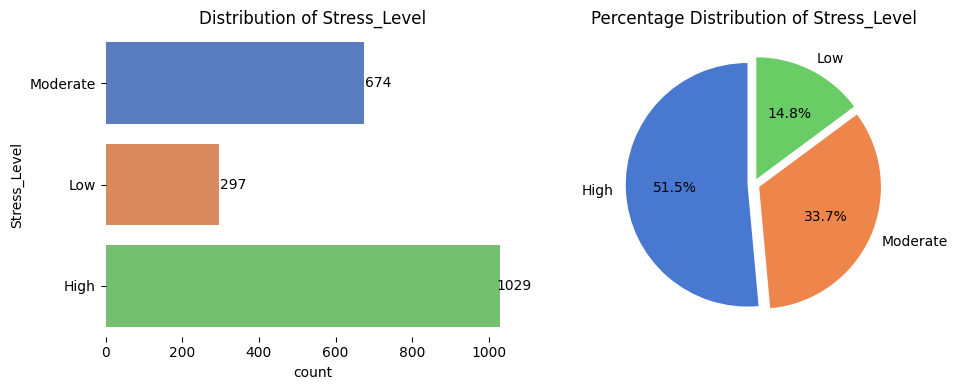

In [64]:
column_name = 'Stress_Level'
plt.figure(figsize=(10, 4))

# First subplot: Count plot
plt.subplot(1, 2, 1)
sns.countplot(y=column_name, data=df, palette='muted')  
plt.title(f'Distribution of {column_name}')

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', xytext=(10, 0), textcoords='offset points')

sns.despine(left=True, bottom=True)

# Second subplot: Pie chart
plt.subplot(1, 2, 2)
df[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90, explode=[0.05]*df[column_name].nunique())
plt.title(f'Percentage Distribution of {column_name}')
plt.ylabel('')  

plt.tight_layout()
plt.show()

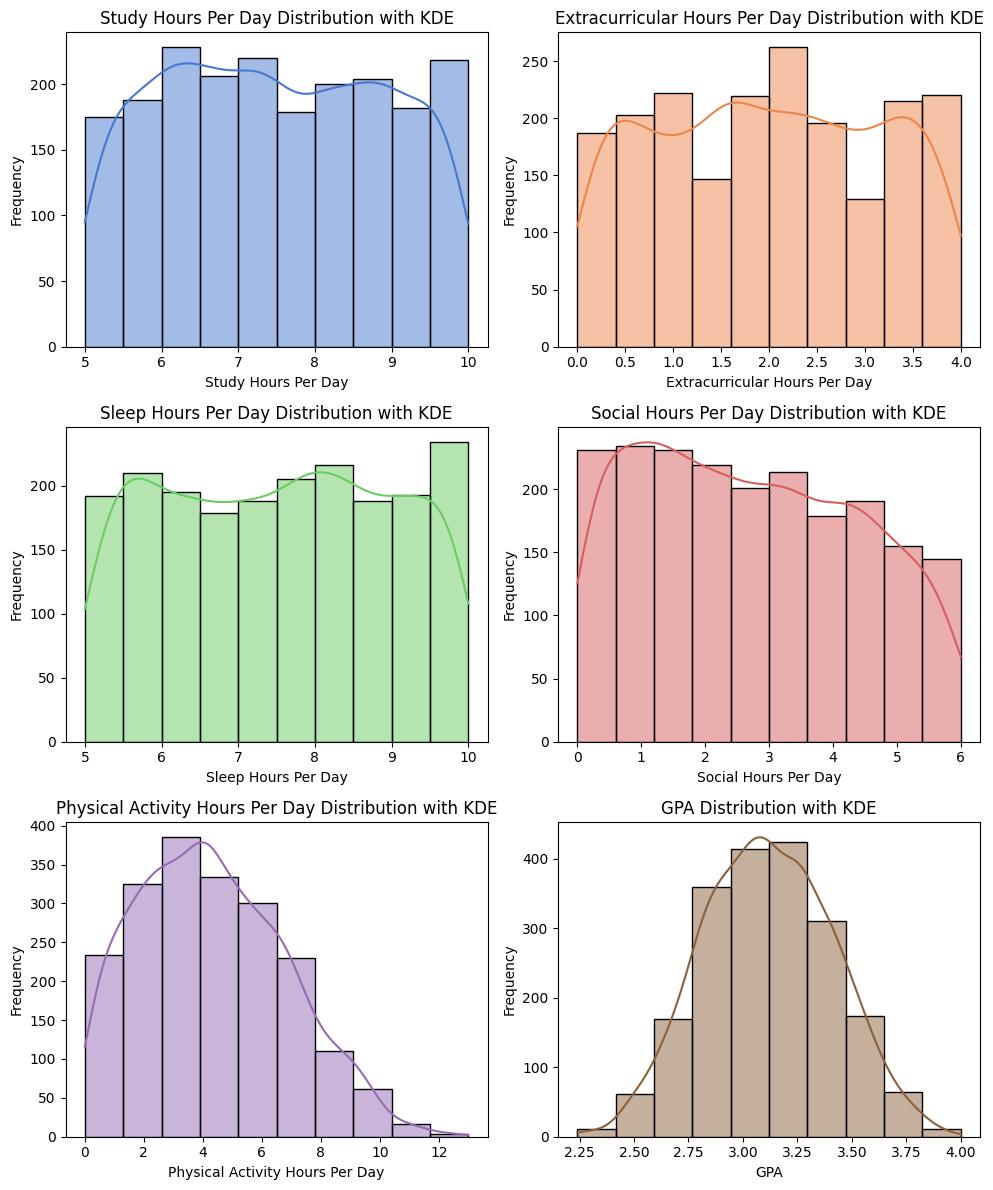

In [65]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(10, 12))  
    
    muted_colors = sns.color_palette("muted", len(columns))
    
    for i, column in enumerate(columns):
        plt.subplot(3, 2, i + 1)  
        sns.histplot(data[column], kde=True, bins=10, color=muted_colors[i])
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

columns_to_analyze = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
                       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 
                       'Physical_Activity_Hours_Per_Day', 'GPA']

univariate_analysis(df, columns_to_analyze)

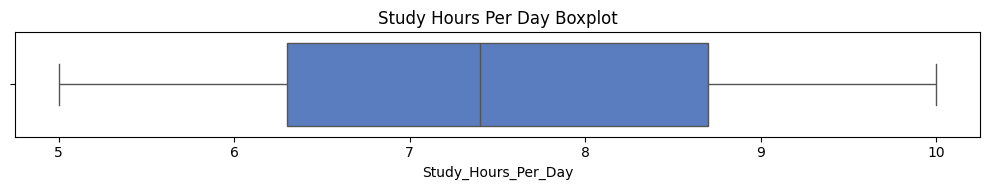


Summary Statistics for Study Hours Per Day:
 count    2000.000000
mean        7.475800
std         1.423888
min         5.000000
25%         6.300000
50%         7.400000
75%         8.700000
max        10.000000
Name: Study_Hours_Per_Day, dtype: float64


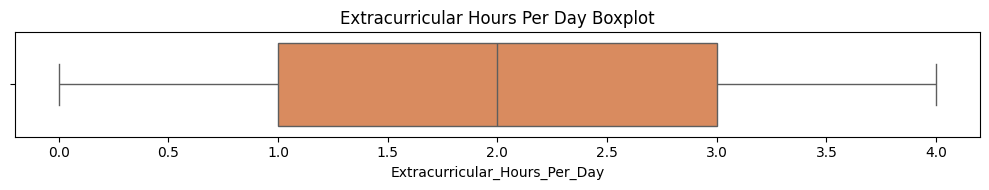


Summary Statistics for Extracurricular Hours Per Day:
 count    2000.000000
mean        1.990100
std         1.155855
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Extracurricular_Hours_Per_Day, dtype: float64


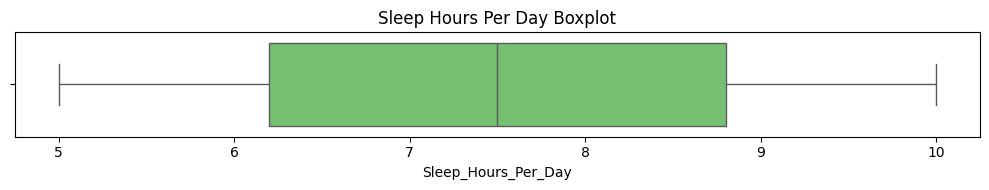


Summary Statistics for Sleep Hours Per Day:
 count    2000.000000
mean        7.501250
std         1.460949
min         5.000000
25%         6.200000
50%         7.500000
75%         8.800000
max        10.000000
Name: Sleep_Hours_Per_Day, dtype: float64


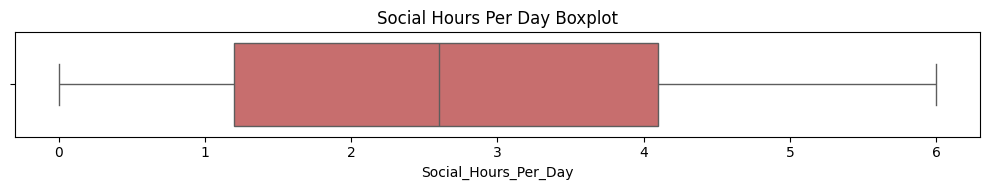


Summary Statistics for Social Hours Per Day:
 count    2000.000000
mean        2.704550
std         1.688514
min         0.000000
25%         1.200000
50%         2.600000
75%         4.100000
max         6.000000
Name: Social_Hours_Per_Day, dtype: float64


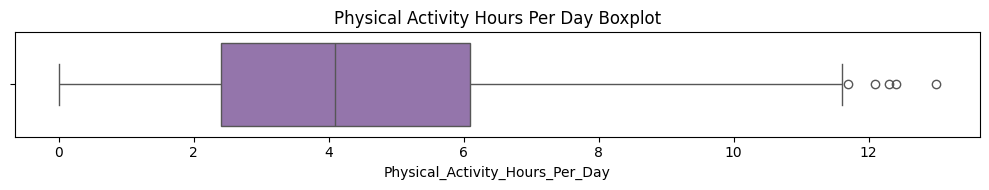


Summary Statistics for Physical Activity Hours Per Day:
 count    2000.00000
mean        4.32830
std         2.51411
min         0.00000
25%         2.40000
50%         4.10000
75%         6.10000
max        13.00000
Name: Physical_Activity_Hours_Per_Day, dtype: float64


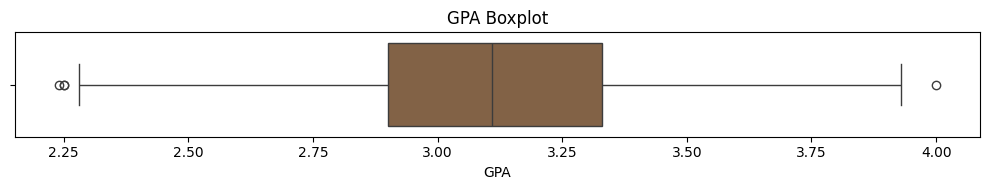


Summary Statistics for GPA:
 count    2000.000000
mean        3.115960
std         0.298674
min         2.240000
25%         2.900000
50%         3.110000
75%         3.330000
max         4.000000
Name: GPA, dtype: float64


In [66]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, column, title):
    plt.figure(figsize=(10, 2))
    
    # Define a muted color palette
    color = sns.color_palette("muted")[columns_to_analyze.index(column)]
    
    sns.boxplot(x=data[column], color=color)
    plt.title(f'{title} Boxplot')
    
    plt.tight_layout()
    plt.show()

    print(f'\nSummary Statistics for {title}:\n', data[column].describe())

# List of columns to analyze
columns_to_analyze = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
                       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 
                       'Physical_Activity_Hours_Per_Day', 'GPA']

# Iterate through columns and perform univariate analysis
for column in columns_to_analyze:
    univariate_analysis(df, column, column.replace('_', ' '))

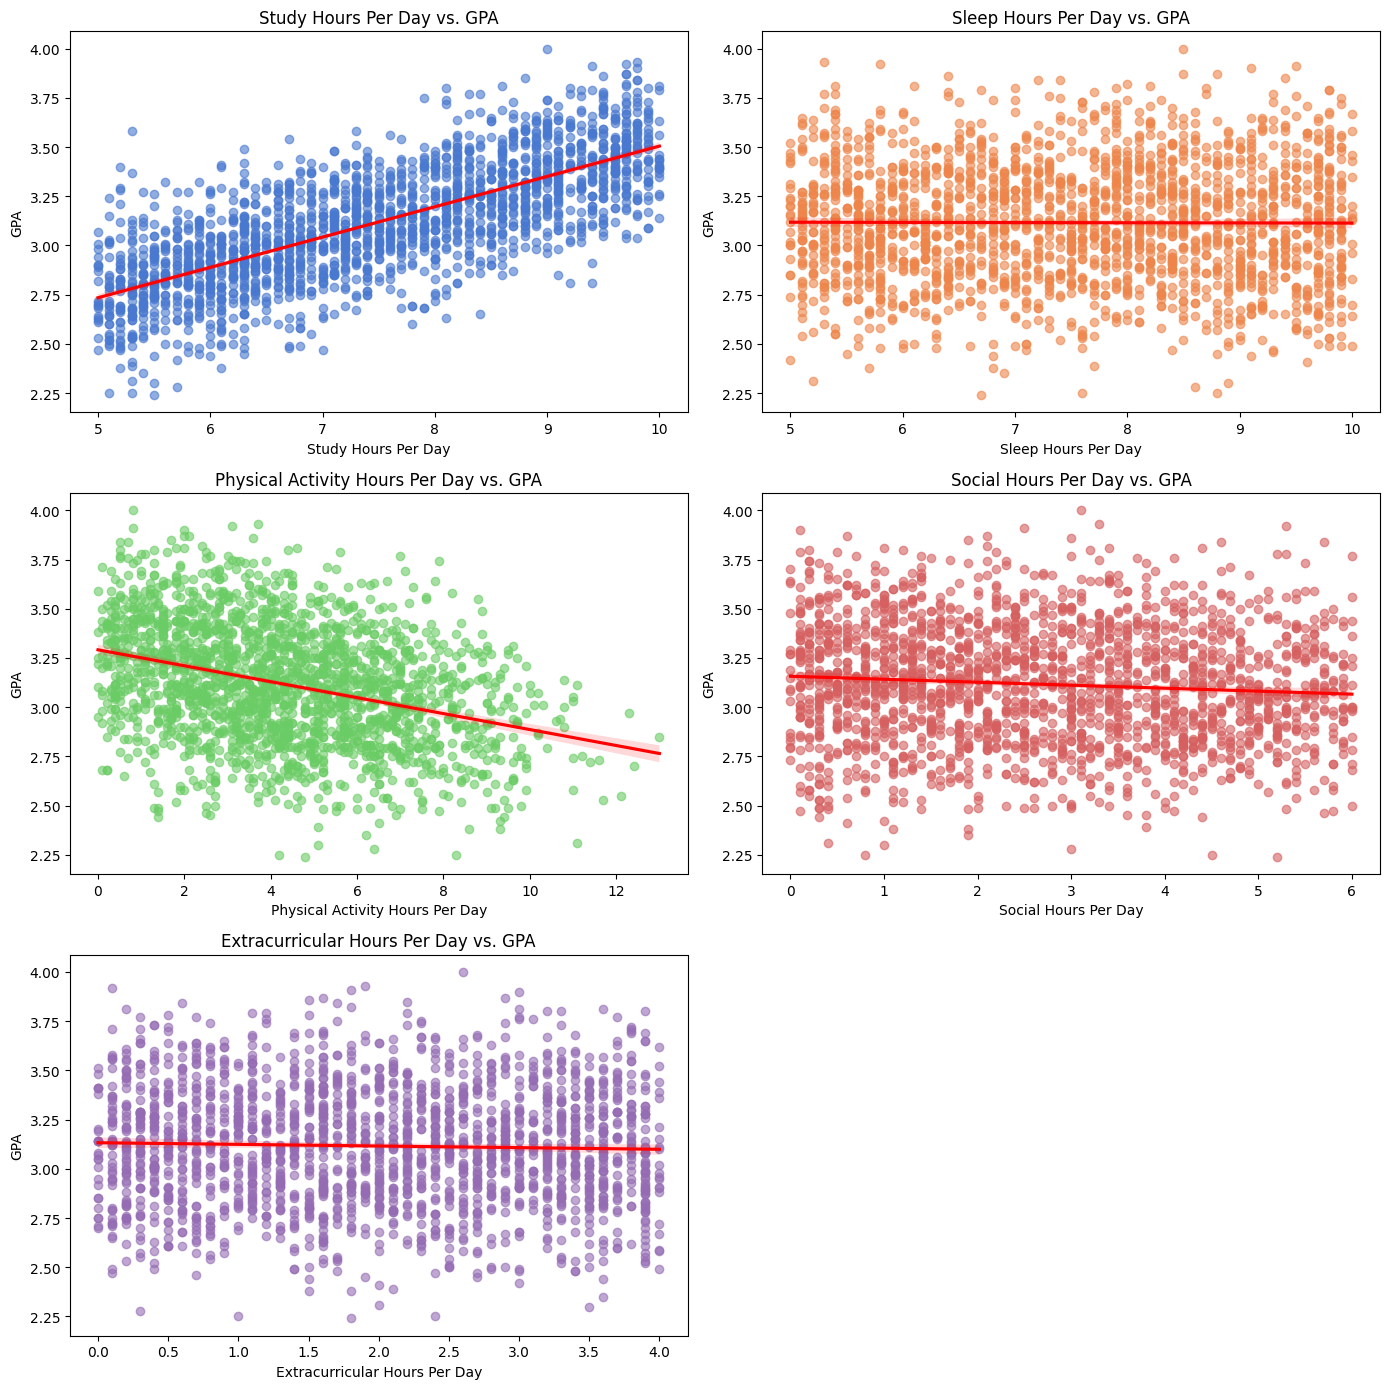

In [67]:
# Define muted colors from the palette
muted_colors = sns.color_palette("muted")

# Scatter plots with linear regression lines 
plt.figure(figsize=(14, 14))

# Study Hours vs. GPA
plt.subplot(3, 2, 1)
sns.regplot(x='Study_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[0], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Study Hours Per Day vs. GPA')
plt.xlabel('Study Hours Per Day')
plt.ylabel('GPA')

# Sleep Hours vs. GPA
plt.subplot(3, 2, 2)
sns.regplot(x='Sleep_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[1], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Sleep Hours Per Day vs. GPA')
plt.xlabel('Sleep Hours Per Day')
plt.ylabel('GPA')

# Physical Activity Hours vs. GPA
plt.subplot(3, 2, 3)
sns.regplot(x='Physical_Activity_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[2], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Physical Activity Hours Per Day vs. GPA')
plt.xlabel('Physical Activity Hours Per Day')
plt.ylabel('GPA')

# Social Hours vs. GPA
plt.subplot(3, 2, 4)
sns.regplot(x='Social_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[3], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Social Hours Per Day vs. GPA')
plt.xlabel('Social Hours Per Day')
plt.ylabel('GPA')

# Extracurricular Hours vs. GPA
plt.subplot(3, 2, 5)
sns.regplot(x='Extracurricular_Hours_Per_Day', y='GPA', data=df,
            color=muted_colors[4], scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Extracurricular Hours Per Day vs. GPA')
plt.xlabel('Extracurricular Hours Per Day')
plt.ylabel('GPA')

plt.tight_layout()
plt.show()

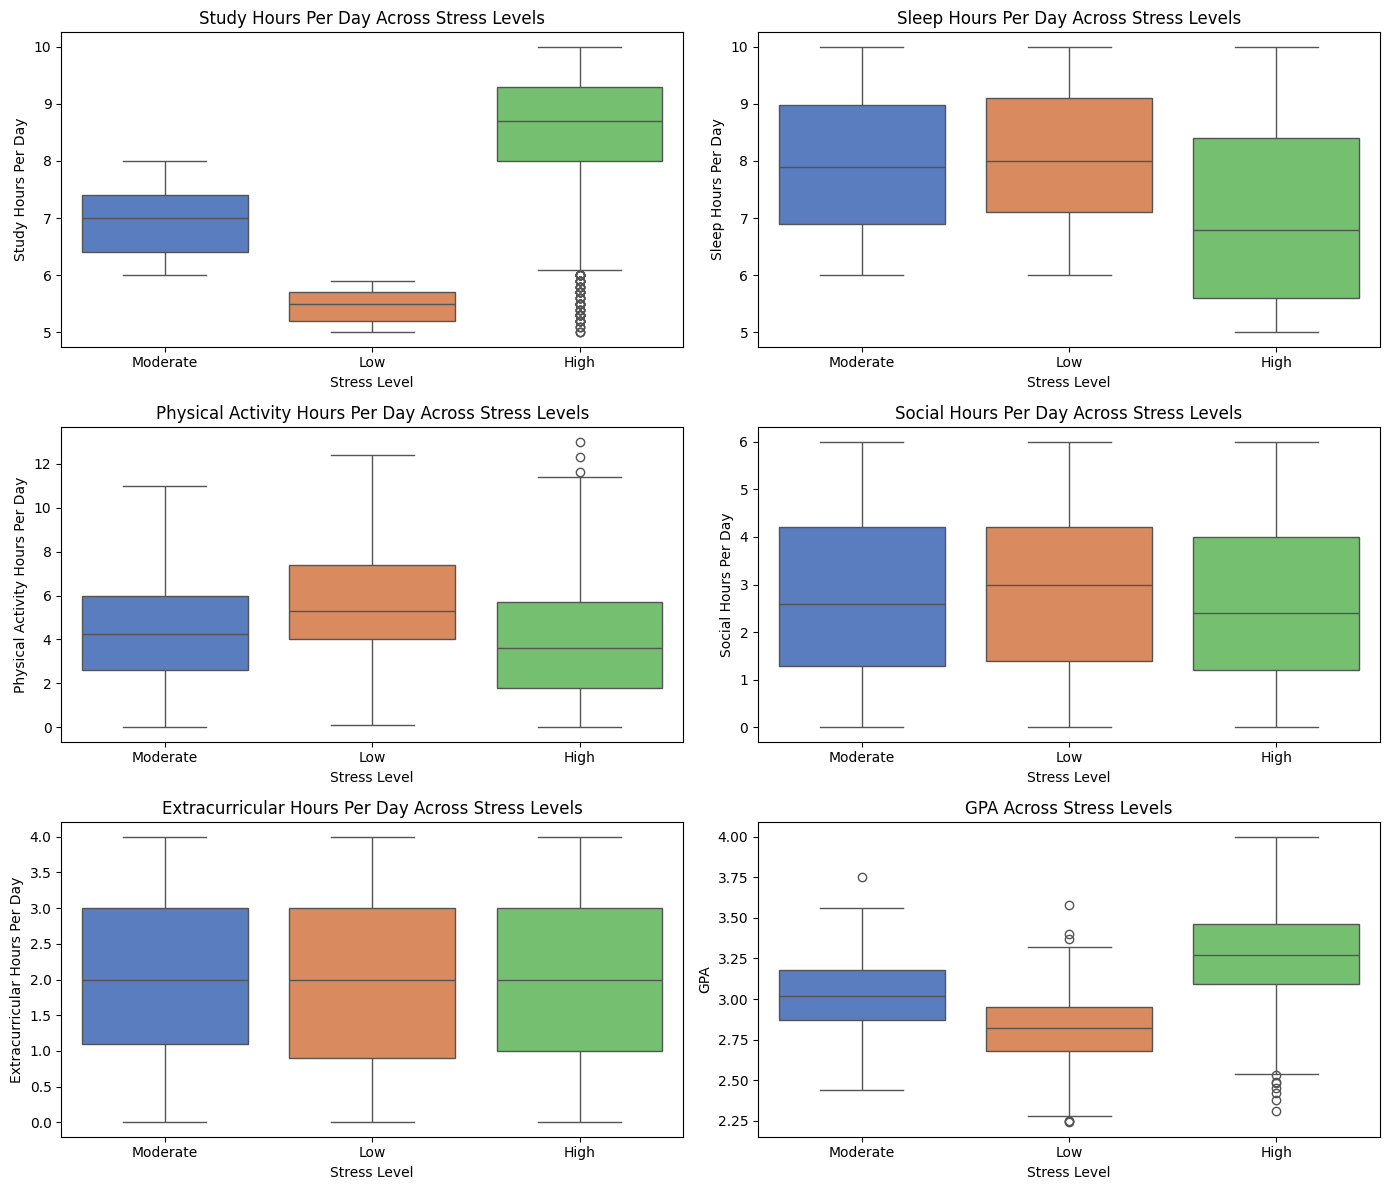

In [68]:
numerical_features = [
    'Study_Hours_Per_Day', 
    'Sleep_Hours_Per_Day', 
    'Physical_Activity_Hours_Per_Day', 
    'Social_Hours_Per_Day', 
    'Extracurricular_Hours_Per_Day',
    'GPA'
]

# Create boxplots for each numerical feature grouped by Stress_Level
plt.figure(figsize=(14, 12))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='Stress_Level', y=feature, data=df, palette='muted')
    plt.title(f'{feature.replace("_", " ")} Across Stress Levels')
    plt.xlabel('Stress Level')
    plt.ylabel(feature.replace("_", " "))

plt.tight_layout()
plt.show()

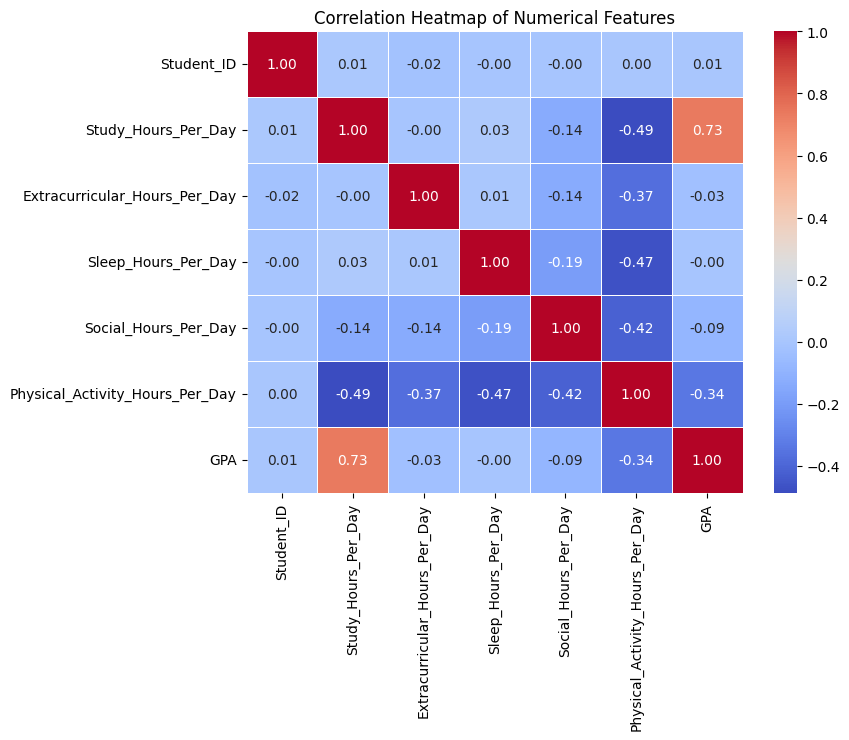

In [69]:
# Plotting a correlation heatmap for numerical variables
plt.figure(figsize=(8, 6))
numerical_columns = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_columns.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

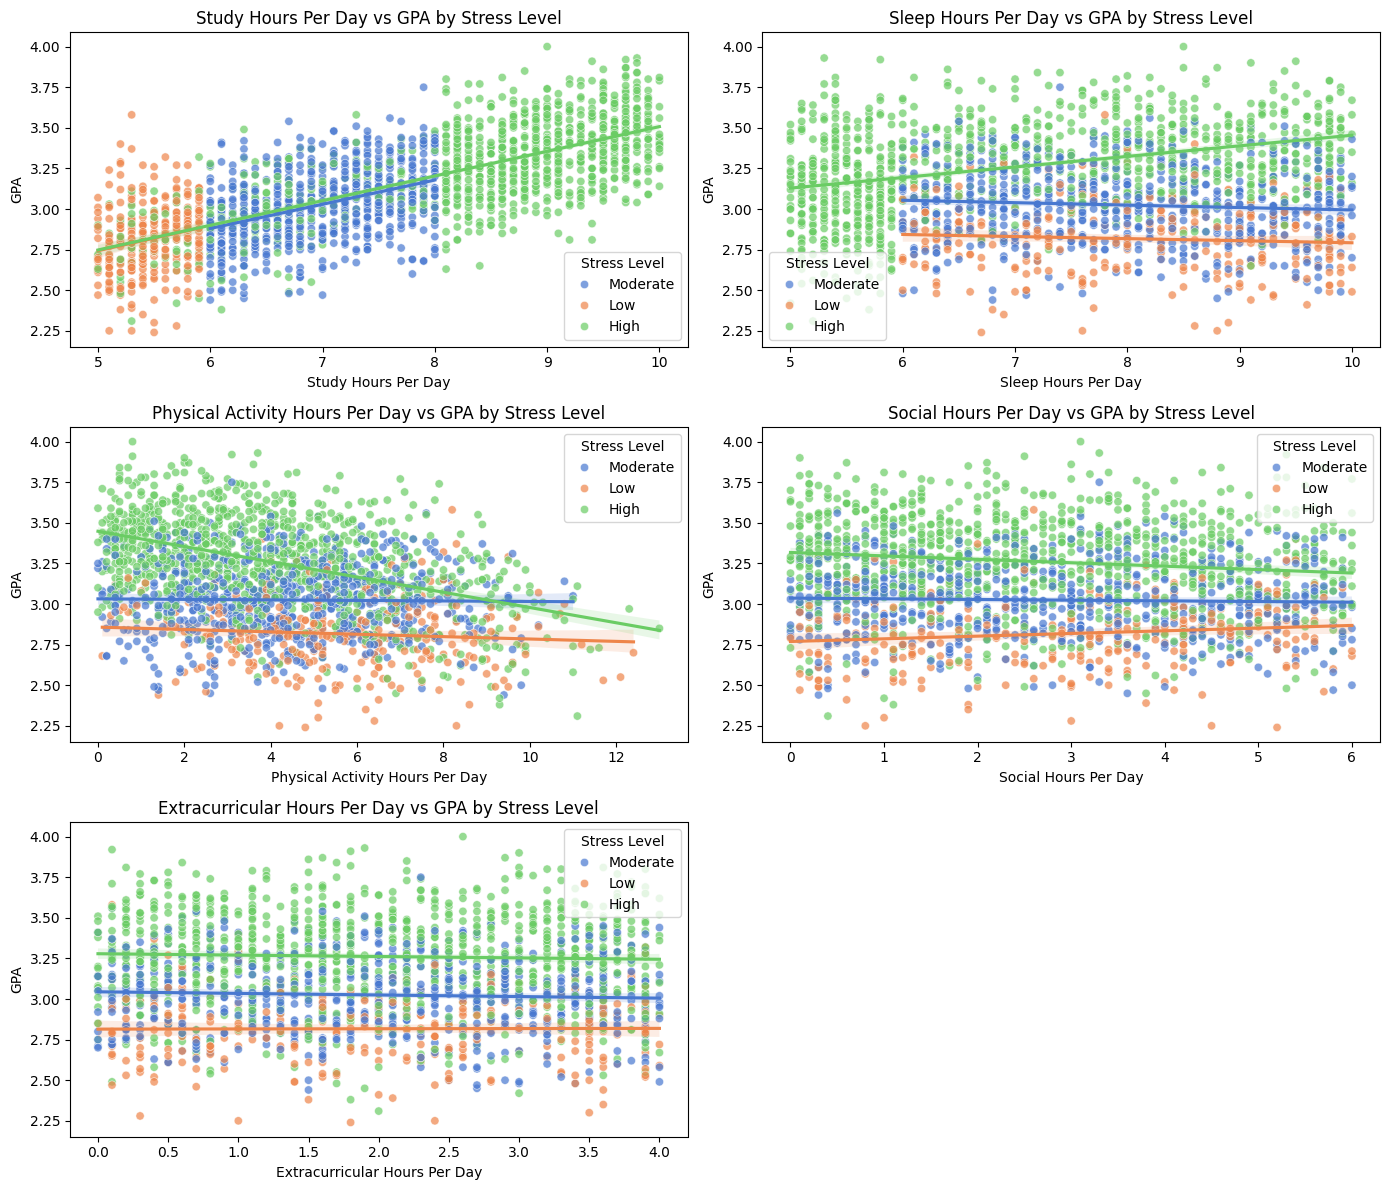

In [70]:
plt.figure(figsize=(14, 12))

numerical_features = [
    'Study_Hours_Per_Day', 
    'Sleep_Hours_Per_Day', 
    'Physical_Activity_Hours_Per_Day', 
    'Social_Hours_Per_Day', 
    'Extracurricular_Hours_Per_Day'
]

# Define colors for different stress levels
stress_colors = sns.color_palette('muted')

# Plot each feature
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    
    # Scatter plot with matching colors for stress levels
    sns.scatterplot(
        x=feature,
        y='GPA',
        hue='Stress_Level',
        data=df,
        palette=stress_colors,
        alpha=0.7
    )
    
    # Add linear regression lines for each stress level with matching colors
    for j, stress_level in enumerate(df['Stress_Level'].unique()):
        sns.regplot(
            x=feature,
            y='GPA',
            data=df[df['Stress_Level'] == stress_level],
            scatter=False,
            color=stress_colors[j], # Use the same color for the line as in the scatter plot
            line_kws={'label': stress_level}
        )
    
    plt.title(f'{feature.replace("_", " ")} vs GPA by Stress Level')
    plt.xlabel(feature.replace('_', ' '))
    plt.ylabel('GPA')
    plt.legend(title='Stress Level')

plt.tight_layout()
plt.show()

In [71]:
# Define thresholds for low and high GPA
low_gpa_threshold = 2.5
high_gpa_threshold = 3.5  

# Filter students with low GPA (less than or equal to the threshold)
low_gpa_students = df[df['GPA'] <= low_gpa_threshold][
    ['GPA', 'Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level']
]

# Display results in a clear format
print("----- Students with Low GPA (<= 2.5) -----")
display(low_gpa_students)

# Filter students with high GPA (equal to the threshold)
high_gpa_students = df[df['GPA'] >= high_gpa_threshold][
    ['GPA', 'Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level']
]

# Display results in a clear format
print("\n----- Students with High GPA (>= 3.5) -----")
display(high_gpa_students)

----- Students with Low GPA (<= 2.5) -----


,GPA,Study_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level
32,2.47,5.2,7.9,Low
56,2.39,5.3,5.1,Low
134,2.45,6.3,2.6,Moderate
158,2.38,6.1,9.3,High
165,2.46,5.8,2.5,Low
283,2.50,6.2,9.8,Moderate
331,2.25,5.1,8.3,Low
377,2.28,5.7,6.4,Low
382,2.31,5.3,11.1,High
504,2.49,5.2,4.6,Low



----- Students with High GPA (>= 3.5) -----


,GPA,Study_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level
4,3.51,8.1,6.6,High
34,3.62,9.7,6.3,High
45,3.55,9.7,0.6,High
51,4.00,9.0,0.8,High
60,3.67,8.3,1.3,High
...,...,...,...,...
1939,3.52,8.1,2.4,High
1962,3.59,9.4,2.9,High
1964,3.54,9.9,3.0,High
1987,3.86,9.5,3.6,High


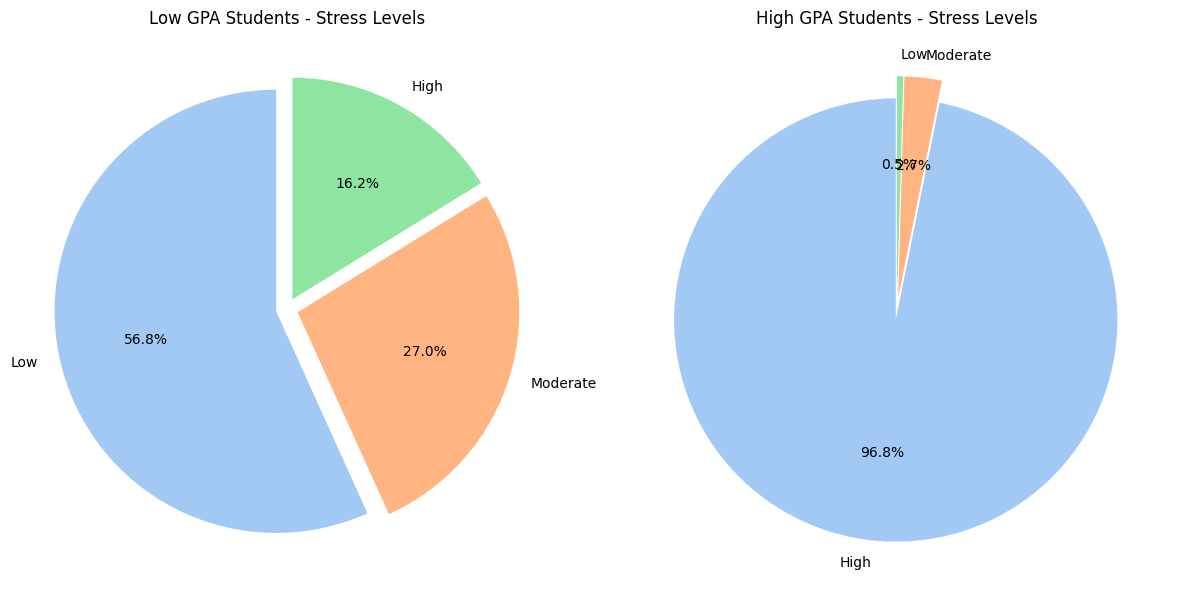

In [72]:
# Prepare data for low GPA students' stress levels
low_gpa_stress_counts = low_gpa_students['Stress_Level'].value_counts()

# Prepare data for high GPA students' stress levels
high_gpa_stress_counts = high_gpa_students['Stress_Level'].value_counts()

# Create subplots for pie charts
plt.figure(figsize=(12, 6))

# Low GPA students' stress levels pie chart
plt.subplot(1, 2, 1)
low_gpa_stress_counts.plot.pie(
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=90, 
    explode=[0.05] * len(low_gpa_stress_counts), 
    labels=low_gpa_stress_counts.index
)
plt.title('Low GPA Students - Stress Levels')
plt.ylabel('')  

# High GPA students' stress levels pie chart
plt.subplot(1, 2, 2)
high_gpa_stress_counts.plot.pie(
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=90, 
    explode=[0.05] * len(high_gpa_stress_counts), 
    labels=high_gpa_stress_counts.index
)
plt.title('High GPA Students - Stress Levels')
plt.ylabel('')  

# Show the plots
plt.tight_layout()
plt.show()

<span style="font-size:24px; font-weight:bold;">Data Preprocessing</span>

## 3.4 Preprocessing — Cek Missing Values
Memeriksa keberadaan nilai kosong (missing values) pada dataset untuk memastikan data telah bersih sebelum pemrosesan lebih lanjut.

In [73]:
missing_values = df.isnull().sum()
print("Jumlah Missing Values per Kolom:\n")
print(missing_values)

# Komentar: Dataset sudah bersih (0 missing values di semua kolom).

Jumlah Missing Values per Kolom:

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64


## 3.4 Preprocessing — Distribusi Kelas (Sebelum SMOTE)
Melihat jumlah data untuk setiap kelas pada kolom target `Stress_Level`. Terdapat masalah imbalance yang akan divisualisasikan dengan bar chart.

Distribusi Kelas (Jumlah):
 Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

Distribusi Kelas (Persentase):
 Stress_Level
High        51.45
Moderate    33.70
Low         14.85
Name: proportion, dtype: float64


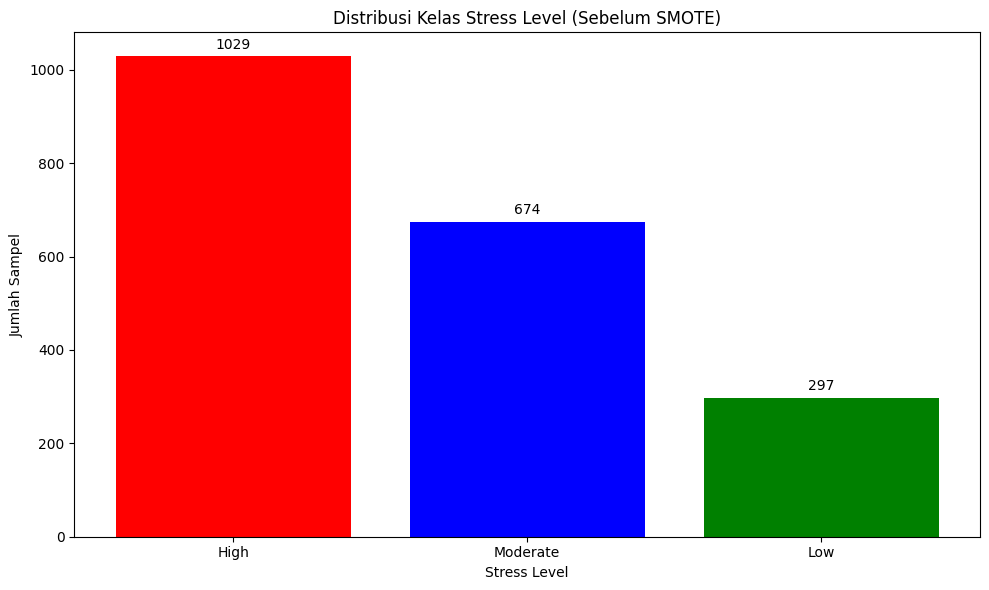

In [74]:
# Evaluasi proporsi kelas
class_counts = df['Stress_Level'].value_counts()
class_percentages = df['Stress_Level'].value_counts(normalize=True) * 100

print("Distribusi Kelas (Jumlah):\n", class_counts)
print("\nDistribusi Kelas (Persentase):\n", class_percentages)

# Visualisasi
plt.figure(figsize=(10, 6))
colors = {'Low': 'green', 'Moderate': 'blue', 'High': 'red'}
bars = plt.bar(class_counts.index, class_counts.values, color=[colors[x] for x in class_counts.index])

plt.title('Distribusi Kelas Stress Level (Sebelum SMOTE)')
plt.xlabel('Stress Level')
plt.ylabel('Jumlah Sampel')

# Anotasi nilai di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3.4 Preprocessing — Label Encoding
Mengubah nilai kategori target menjadi angka yang berurutan (0, 1, 2) agar sesuai dan terkontrol urutannya (Low=0, Moderate=1, High=2), menggunakan mapping dictionary.

In [75]:
# Mapping dictionary manual untuk mempertahankan urutan numerik skala stres
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level_encoded'] = df['Stress_Level'].map(stress_mapping)

print("Mapping yang digunakan:", stress_mapping)
print("\n5 Baris Pertama Hasil Encoding:")
display(df[['Stress_Level', 'Stress_Level_encoded']].head())

Mapping yang digunakan: {'Low': 0, 'Moderate': 1, 'High': 2}

5 Baris Pertama Hasil Encoding:


,Stress_Level,Stress_Level_encoded
0,Moderate,1
1,Low,0
2,Low,0
3,Moderate,1
4,High,2


## 3.4 Preprocessing — Statistik Deskriptif per Kelas
Mengelompokkan data berdasarkan tingkat stres dan menghitung rata-rata nilai dari masing-masing fitur numerik, untuk memahami pola dari kelas target.

In [76]:
# Menghitung rata-rata setiap fitur per Stress_Level
features = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
            'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 
            'Physical_Activity_Hours_Per_Day', 'GPA']

stats_per_class = df.groupby('Stress_Level_encoded')[features].mean().round(3)

# Memetakan kembali index sesuai tingkat stres untuk tampilan
display(stats_per_class)

# Komentar: Terlihat bahwa High stress memiliki pola tersendiri dibanding kelas lainnya.

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
Stress_Level_encoded,,,,,,
0,5.474,1.989,8.064,2.891,5.582,2.817
1,6.970,2.006,7.948,2.740,4.337,3.025
2,8.385,1.980,7.046,2.628,3.961,3.262


## 3.4 Preprocessing — Heatmap Korelasi
Menganalisis matriks korelasi Pearson antara semua fitur numerik dan variabel target (setelah di-encode) menggunakan Heatmap, untuk mengetahui hubungan linier antar variabel.

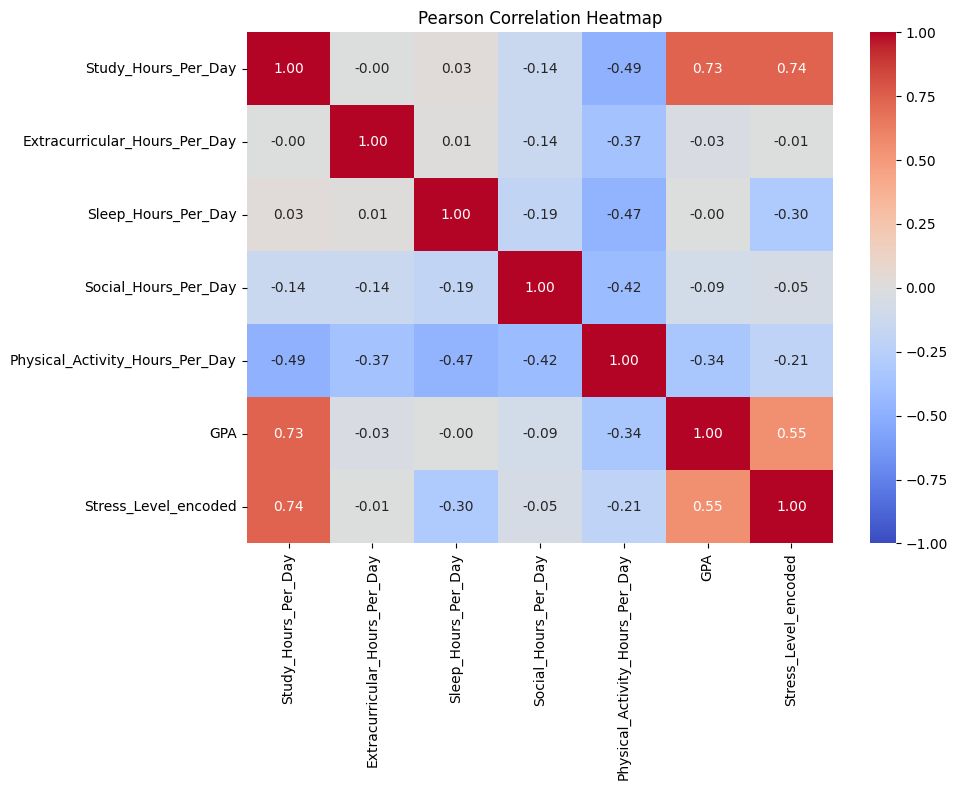

In [77]:
# Menggunakan fitur dan label yang sudah diencode
cols_to_corr = features + ['Stress_Level_encoded']
corr_matrix = df[cols_to_corr].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3.4 Preprocessing — Boxplot Distribusi per Kelas
Menampilkan sebaran dan distribusi kuartil dari 6 fitur masukan yang dikelompokkan menurut 3 kategori kelas menggunakan Boxplot, mempermudah melihat *outliers* secara visual.

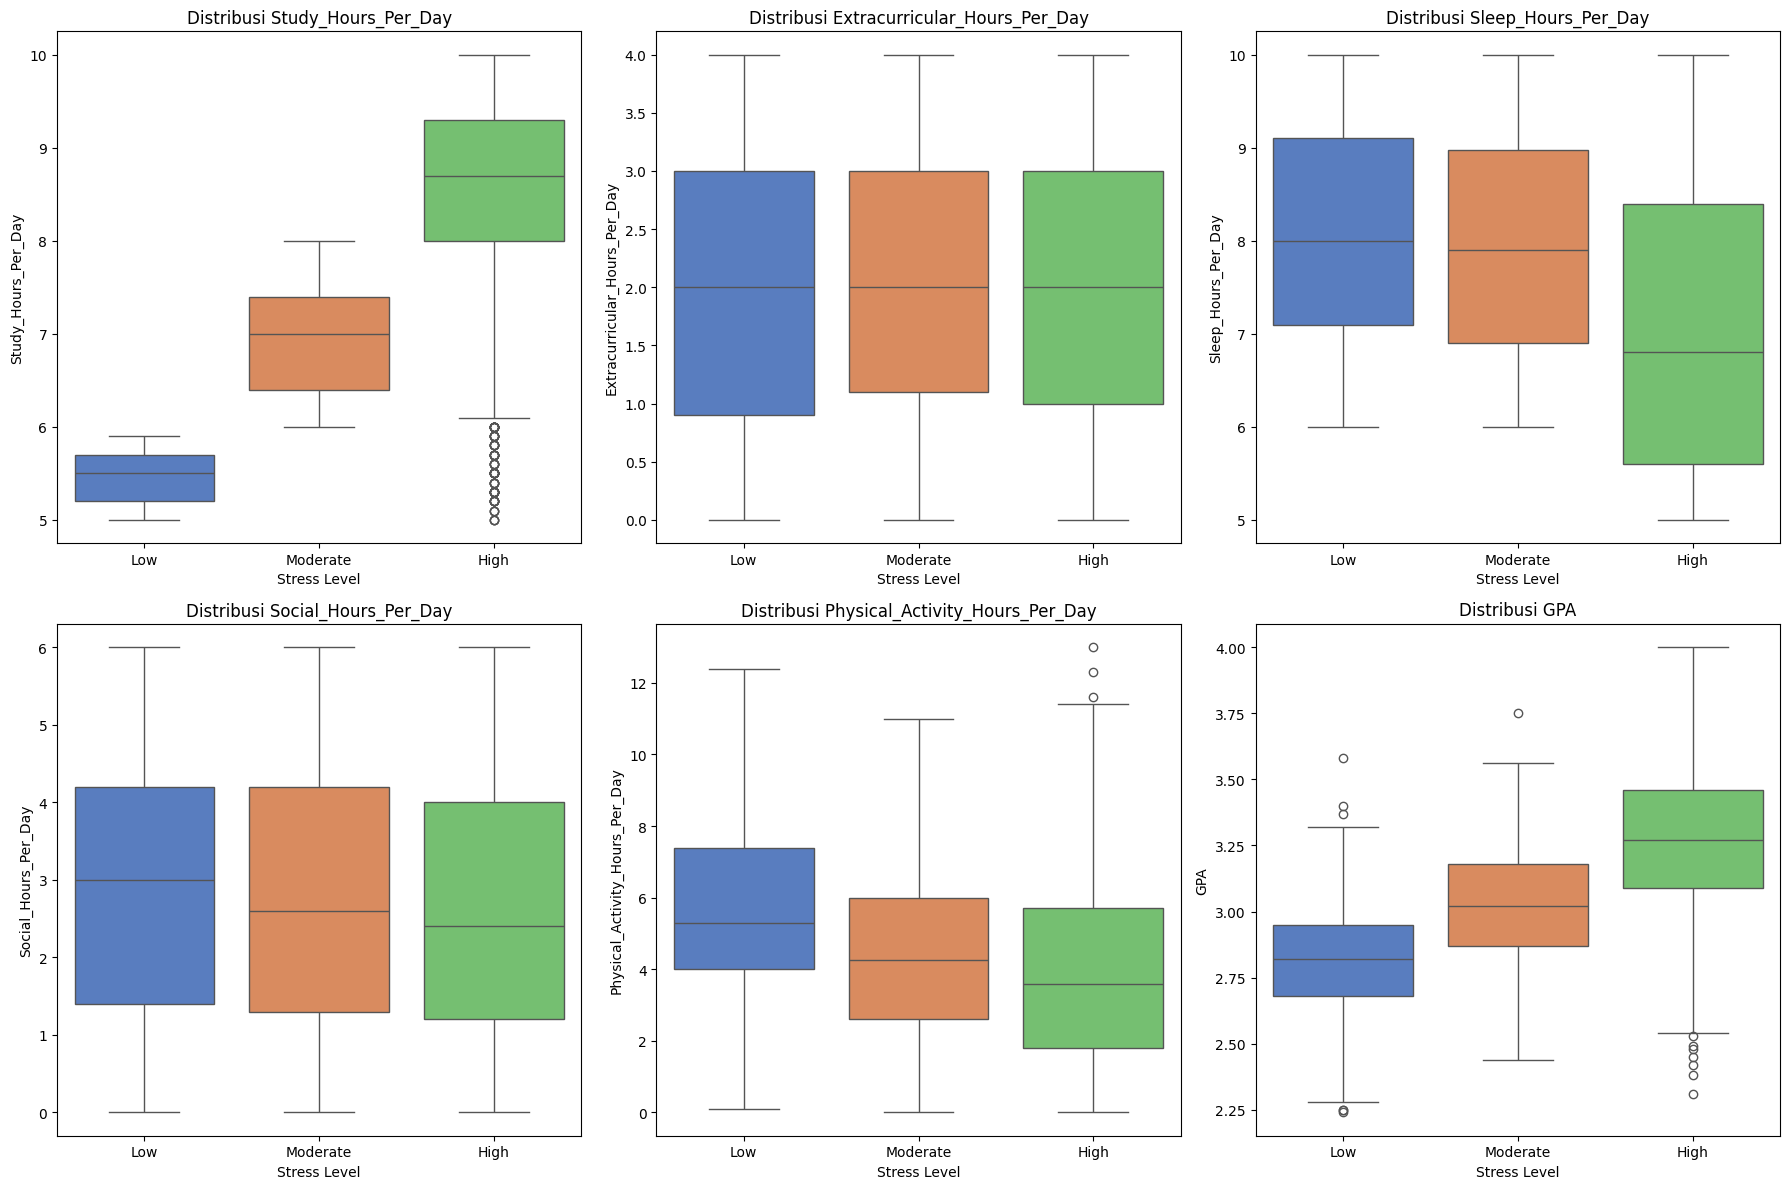

In [78]:
plt.figure(figsize=(18, 12))
stress_order = ['Low', 'Moderate', 'High']

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Stress_Level', y=feature, data=df, order=stress_order, palette='muted')
    plt.title(f'Distribusi {feature}')
    plt.xlabel('Stress Level')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

## 3.4 Preprocessing — Normalisasi (StandardScaler)
Melakukan pembagian data (train and test split) dengan rasio 80:20 serta menormalisasi data dengan menggunakan StandardScaler yang di-fit hanya di data training untuk mencegah *data leakage*.

In [79]:
X = df[features]
y = df['Stress_Level_encoded']

# Split data 80:20, startify=y akan memastikan proporsi kelas terjaga
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Inisialisasi StandardScaler dan fit HANYA di X_train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Mengubah kembali menjadi DataFrame untuk kemudahan analisis selanjutnya
X_train = pd.DataFrame(X_train, columns=features)
X_test = pd.DataFrame(X_test, columns=features)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (1600, 6)
Shape X_test: (400, 6)
Shape y_train: (1600,)
Shape y_test: (400,)


## 3.5 Penanganan Imbalanced Data — SMOTE
Menyeimbangkan proporsi kelas minoritas dengan mensintesis (oversampling) kelas 'Moderate' dan 'Low' agar berimbang dengan kelas 'High'. Diterapkan HANYA pada himpunan data latih.

Sebelum SMOTE (y_train):
Stress_Level_encoded
0    238
1    539
2    823
Name: count, dtype: int64

Sesudah SMOTE (y_train_resampled):
Stress_Level_encoded
0    823
1    823
2    823
Name: count, dtype: int64


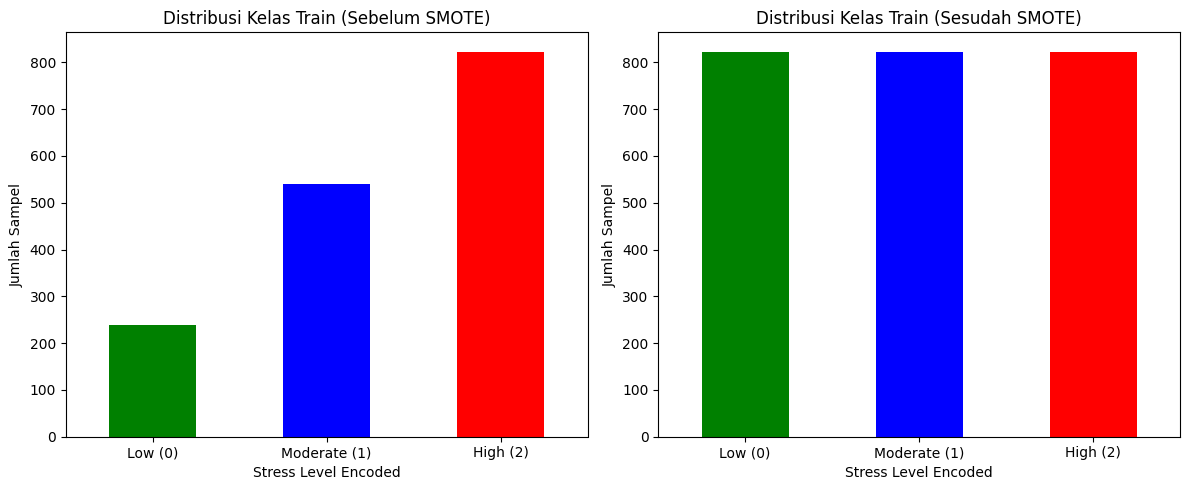

In [80]:
# Distribusi kelas sebelum SMOTE pada data train
print("Sebelum SMOTE (y_train):")
print(y_train.value_counts().sort_index())

# Terapkan SMOTE pada X_train saja
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Distribusi sesudah SMOTE pada data train
print("\nSesudah SMOTE (y_train_resampled):")
print(y_train_resampled.value_counts().sort_index())

# Visualisasi Bar Chart After vs Before
plt.figure(figsize=(12, 5))

# Subplot 1: Sebelum SMOTE
plt.subplot(1, 2, 1)
y_train.value_counts().sort_index().plot(kind='bar', color=['green', 'blue', 'red'])
plt.title('Distribusi Kelas Train (Sebelum SMOTE)')
plt.xlabel('Stress Level Encoded')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[0, 1, 2], labels=['Low (0)', 'Moderate (1)', 'High (2)'], rotation=0)

# Subplot 2: Sesudah SMOTE
plt.subplot(1, 2, 2)
y_train_resampled.value_counts().sort_index().plot(kind='bar', color=['green', 'blue', 'red'])
plt.title('Distribusi Kelas Train (Sesudah SMOTE)')
plt.xlabel('Stress Level Encoded')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=[0, 1, 2], labels=['Low (0)', 'Moderate (1)', 'High (2)'], rotation=0)

plt.tight_layout()
plt.show()

## 3.8 Hyperparameter Tuning — Setup GridSearchCV
Mempersiapkan alat validasi silang berupa `StratifiedKFold` serta grid parameter (`param_grid`) masing-masing model untuk mencari konfigurasi hiperparameter yang optimal secara objektif.

In [81]:
# Setup Cross Validation: menggunakan StratifiedKFold k=5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metric = 'f1_weighted'

# Setup Model
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
lr_model = LogisticRegression(random_state=42)
svm_model = SVC(probability=True, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

# Parameter Grids
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

dt_params = {
    'max_depth': [3, 5, 10, 15, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Setup GridSearchCV berhasil disiapkan.")

Setup GridSearchCV berhasil disiapkan.


## 3.8 Hyperparameter Tuning — Random Forest
Mencari konfigurasi terbaik model ensemble Random Forest dengan berbagai nilai n_estimators dan kedalaman pohon.

In [82]:
gs_rf = GridSearchCV(estimator=rf_model, param_grid=rf_params, 
                     scoring=scoring_metric, cv=skf, n_jobs=-1)
gs_rf.fit(X_train_resampled, y_train_resampled)

print("=== Hasil Random Forest ===")
print(f"Best Parameters: {gs_rf.best_params_}")
print(f"Best CV F1-Score: {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_

=== Hasil Random Forest ===
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score: 1.0000


## 3.8 Hyperparameter Tuning — XGBoost
Mencari konfigurasi terbaik pada model Extreme Gradient Boosting berdasarkan learning_rate, kedalaman, serta penentuan jumlah estimator.

In [83]:
gs_xgb = GridSearchCV(estimator=xgb_model, param_grid=xgb_params, 
                      scoring=scoring_metric, cv=skf, n_jobs=-1)
gs_xgb.fit(X_train_resampled, y_train_resampled)

print("=== Hasil XGBoost ===")
print(f"Best Parameters: {gs_xgb.best_params_}")
print(f"Best CV F1-Score: {gs_xgb.best_score_:.4f}")

best_xgb = gs_xgb.best_estimator_

=== Hasil XGBoost ===
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best CV F1-Score: 1.0000


## 3.8 Hyperparameter Tuning — Logistic Regression
Mengoptimalkan koefisien penalti dan C parameter dari Logistic Regression dengan penalti L1/L2.

In [84]:
gs_lr = GridSearchCV(estimator=lr_model, param_grid=lr_params, 
                     scoring=scoring_metric, cv=skf, n_jobs=-1)
gs_lr.fit(X_train_resampled, y_train_resampled)

print("=== Hasil Logistic Regression ===")
print(f"Best Parameters: {gs_lr.best_params_}")
print(f"Best CV F1-Score: {gs_lr.best_score_:.4f}")

best_lr = gs_lr.best_estimator_

=== Hasil Logistic Regression ===
Best Parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1-Score: 0.8624


## 3.8 Hyperparameter Tuning — SVM
Mencari margin optimal hyperplanes menggunakan SVM melalui kombinasi nilai C, kernel (rbf atau linear), dan gamma.

In [85]:
gs_svm = GridSearchCV(estimator=svm_model, param_grid=svm_params, 
                      scoring=scoring_metric, cv=skf, n_jobs=-1)
gs_svm.fit(X_train_resampled, y_train_resampled)

print("=== Hasil SVM ===")
print(f"Best Parameters: {gs_svm.best_params_}")
print(f"Best CV F1-Score: {gs_svm.best_score_:.4f}")

best_svm = gs_svm.best_estimator_

=== Hasil SVM ===
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-Score: 0.9833


## 3.8 Hyperparameter Tuning — Decision Tree
Mencari parameter pemisah ideal dari sebuah node tunggal Decision Tree.

In [86]:
gs_dt = GridSearchCV(estimator=dt_model, param_grid=dt_params, 
                     scoring=scoring_metric, cv=skf, n_jobs=-1)
gs_dt.fit(X_train_resampled, y_train_resampled)

print("=== Hasil Decision Tree ===")
print(f"Best Parameters: {gs_dt.best_params_}")
print(f"Best CV F1-Score: {gs_dt.best_score_:.4f}")

best_dt = gs_dt.best_estimator_

=== Hasil Decision Tree ===
Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-Score: 1.0000


## 3.8 Ringkasan Hasil Hyperparameter Tuning
Menyandingkan seluruh F1-Score training validation dari setiap model agar mudah diidentifikasi mana yang berkinerja terbaik pada tahap validasi latih.

In [87]:
summary_tuning = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression', 'SVM', 'Decision Tree'],
    'Best Parameters': [str(gs_rf.best_params_), str(gs_xgb.best_params_), 
                        str(gs_lr.best_params_), str(gs_svm.best_params_), 
                        str(gs_dt.best_params_)],
    'Best CV F1-Score (weighted)': [gs_rf.best_score_, gs_xgb.best_score_, 
                                    gs_lr.best_score_, gs_svm.best_score_, 
                                    gs_dt.best_score_]
})

display(summary_tuning)

,Model,Best Parameters,Best CV F1-Score (weighted)
0,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",1.000000
1,XGBoost,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",1.000000
2,Logistic Regression,"{'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', ...",0.862366
3,SVM,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.983331
4,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",1.000000


## 3.11 Evaluasi Model — Semua Algoritma
Melakukan evaluasi tahap akhir pad algoritma dengan data testing yang original (tanpa SMOTE/oversample) untuk mengukur objektif performa riil menggunakan metriks Accuracy, Precision, Recall, F1, & AUC.

In [88]:
# Simpan model terbaik ke dictionary
best_models = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'Logistic Regression': best_lr,
    'SVM': best_svm,
    'Decision Tree': best_dt
}

results_dict = {}
predictions_dict = {}

for model_name, model in best_models.items():
    # Prediksi menggunakan X_test
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)  # Untuk komputasi AUC
    predictions_dict[model_name] = y_pred
    
    # Hitung metrics 'weighted'
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    
    results_dict[model_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    }

print("Semua evaluasi model pada test data selesai diproses.")

Semua evaluasi model pada test data selesai diproses.


## 3.11 Tabel Perbandingan Performa Semua Model
Menyusun DataFrame akhir dari hasil kalkulasi lima algoritma serta meng-highlight baris yang memiliki perolehan indeks F1-score maksimum.

In [89]:
df_results = pd.DataFrame(results_dict).T
df_results = df_results.round(4)
df_results.reset_index(inplace=True)
df_results.rename(columns={'index': 'Model'}, inplace=True)

# Menyorot F1-Score tertinggi
highlighted_results = df_results.style.highlight_max(subset=['F1-Score'], color='lightgreen')
display(highlighted_results)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,Logistic Regression,0.845000,0.848200,0.845000,0.844900,0.949200
3,SVM,0.970000,0.970000,0.970000,0.970000,0.997900
4,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000


## 3.11 Visualisasi — Bar Chart Perbandingan Metrik
Menyediakan tinjauan visual komparatif performa kelima algoritma yang dipisahkan secara mendetail melalui kelima matriks yang diamati.

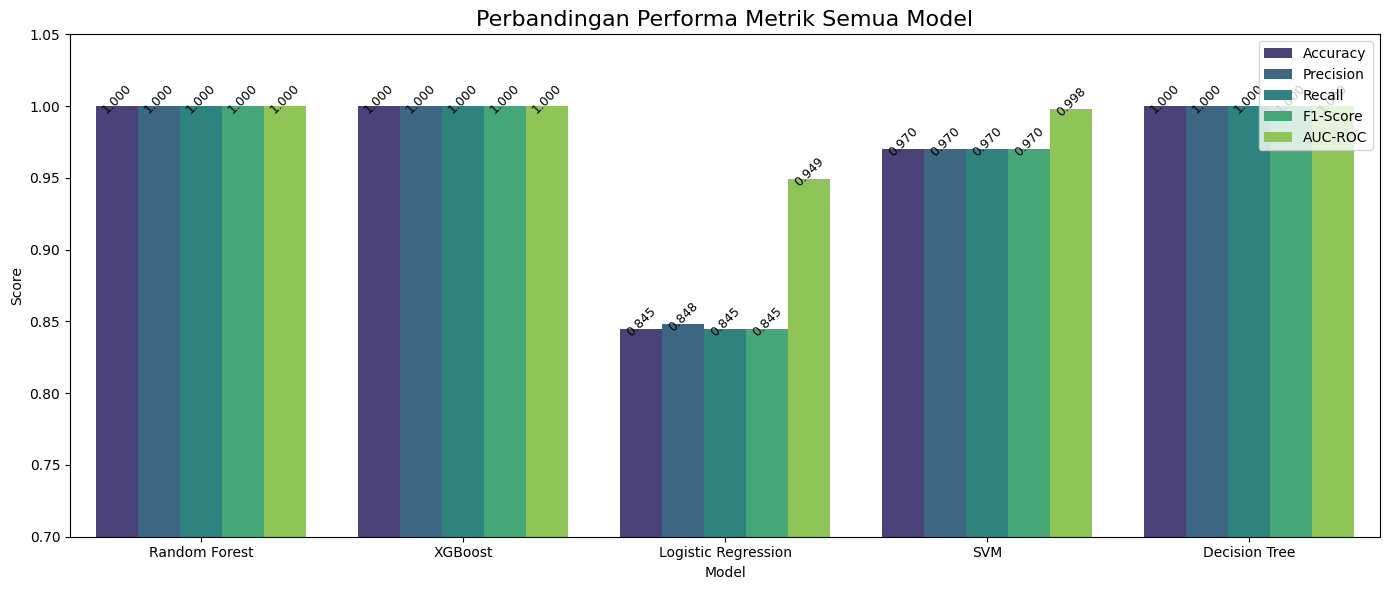

In [90]:
plt.figure(figsize=(14, 6))

df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Perbandingan Performa Metrik Semua Model', fontsize=16)
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0.7, 1.05) # Memfokuskan grafik di range tinggi performa
plt.legend(loc='upper right')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=9, xytext=(0, 5), textcoords='offset points', rotation=45)

plt.tight_layout()
plt.show()

## 3.11 Confusion Matrix — Semua Model
Menampilkan *Confusion Matrix* yang mengungkap taburan observasi aktual versus tebakan setiap model untuk mengetahui letak bias prediksi pada setiap kelasnya (Low, Mod, High).

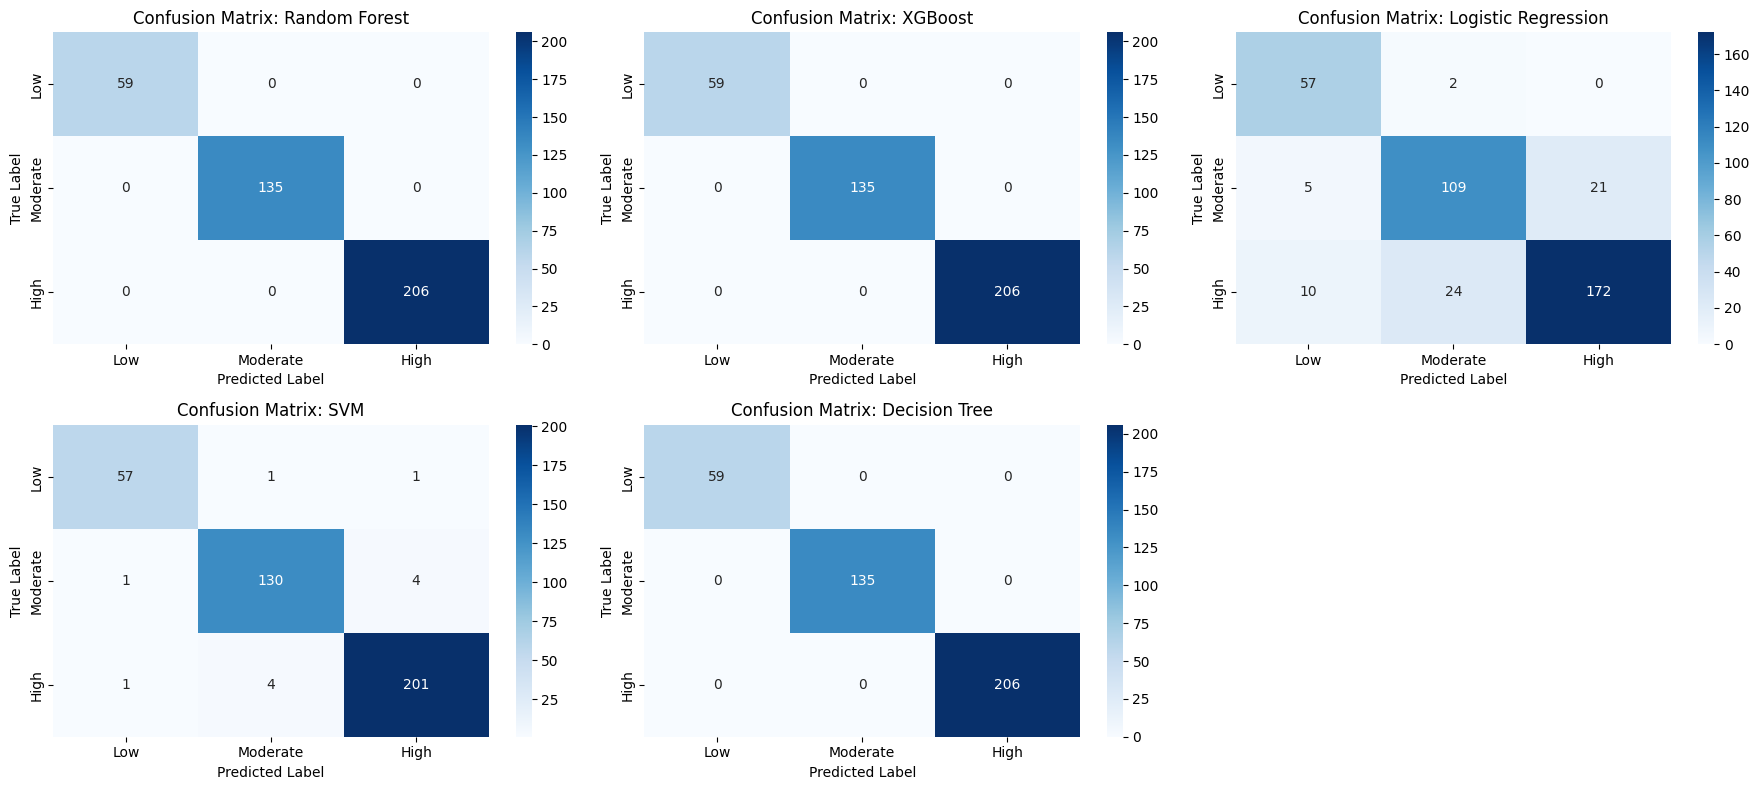

In [91]:
plt.figure(figsize=(18, 8))
class_names = ['Low', 'Moderate', 'High']

for i, (model_name, y_pred) in enumerate(predictions_dict.items(), 1):
    plt.subplot(2, 3, i)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## 3.10 Feature Importance — SHAP Analysis
Mengestimasi seberapa besar kontribusi absolut masing-masing fitur bagi kelas prediksi menggunakan pendekatan SHapley Additive exPlanations (SHAP) untuk model.


--- Memproses SHAP untuk Random Forest ---


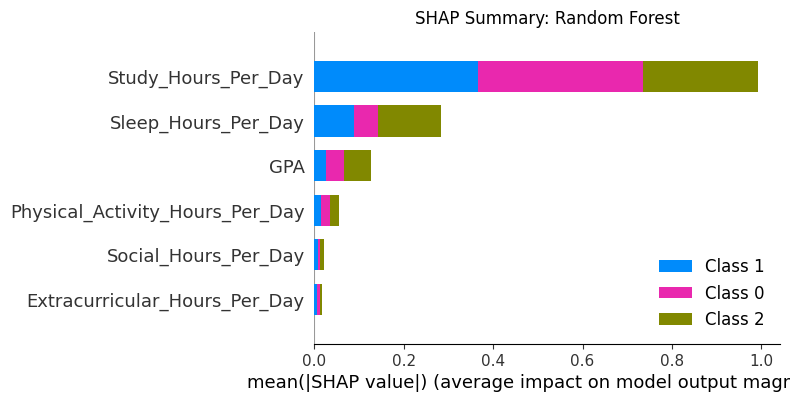


--- Memproses SHAP untuk XGBoost ---


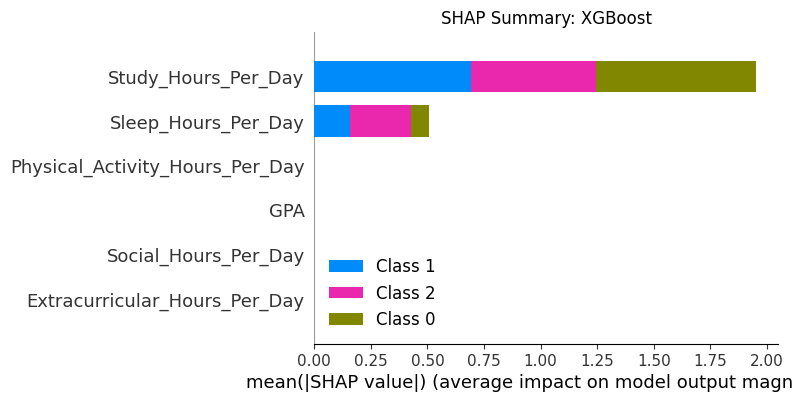


--- Memproses SHAP untuk Logistic Regression ---


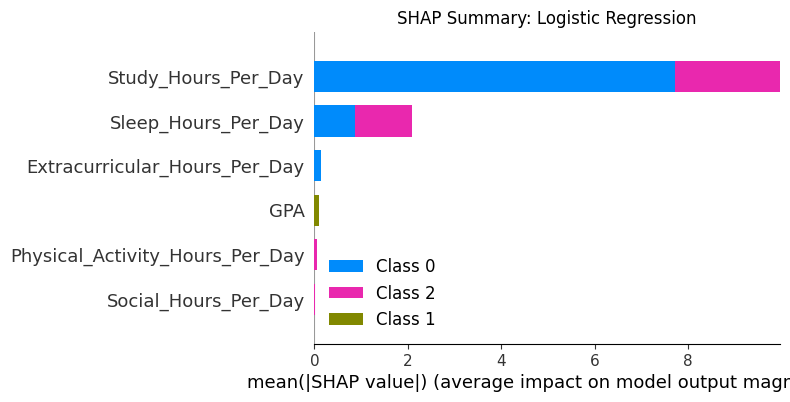


--- Memproses SHAP untuk SVM ---


  0%|          | 0/50 [00:00<?, ?it/s]

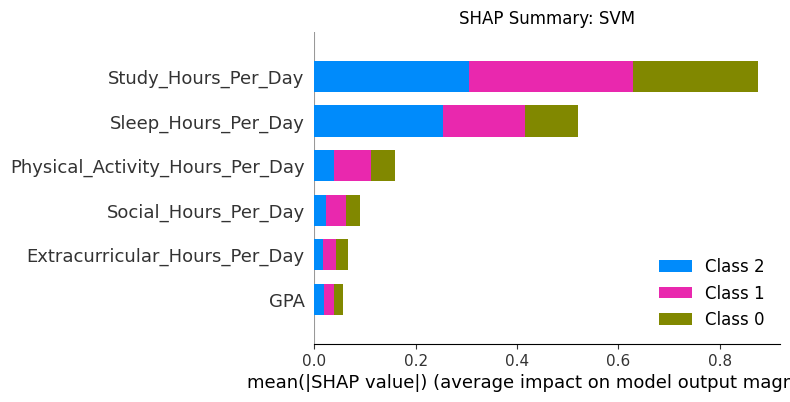


--- Memproses SHAP untuk Decision Tree ---


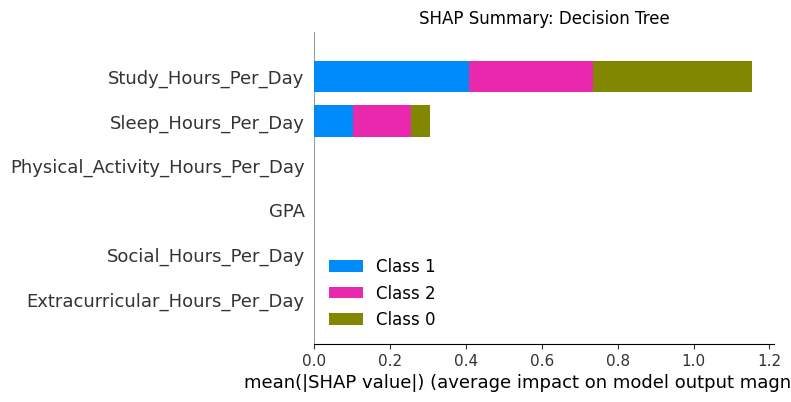

In [92]:
shap_dict = {}

for model_name, model in best_models.items():
    print(f"\n--- Memproses SHAP untuk {model_name} ---")
    
    if model_name in ['Random Forest', 'XGBoost', 'Decision Tree']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train_resampled)
        if len(np.shape(shap_values)) > 2:
            shap_vals_arr = np.array(shap_values)
        else:
            shap_vals_arr = shap_values
        shap_dict[model_name] = np.abs(shap_vals_arr).mean(axis=(0,1)) if len(np.shape(shap_vals_arr)) == 3 else np.abs(shap_vals_arr).mean(axis=0)
        shap.summary_plot(shap_values, X_train_resampled, plot_type="bar", feature_names=features, show=False)
        plt.title(f"SHAP Summary: {model_name}")
        plt.show()
        
    elif model_name == 'Logistic Regression':
        explainer = shap.LinearExplainer(model, X_train_resampled)
        shap_values = explainer.shap_values(X_test)
        shap_dict[model_name] = np.abs(np.array(shap_values)).mean(axis=(0,1))
        shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar', show=False)
        plt.title(f"SHAP Summary: {model_name}")
        plt.show()
        
    elif model_name == 'SVM':
        background = shap.sample(X_train_resampled, 100, random_state=42)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(X_test.sample(50, random_state=42))
        shap_dict[model_name] = np.abs(np.array(shap_values)).mean(axis=(0,1))
        shap.summary_plot(shap_values, X_test.sample(50, random_state=42), feature_names=features, plot_type='bar', show=False)
        plt.title(f"SHAP Summary: {model_name}")
        plt.show()

## 3.10 Feature Importance — Built-in (Gini/Gain/Koefisien)
Mengekstraksi kepentingan bawaan fitur seperti indikator Gini (RF/DT), Information Gain (XGB), dan magnitud koefisen (LR) dari masing-masing algoritma dan digambarkan ke dalam bentuk Horizontal Bar Plot.

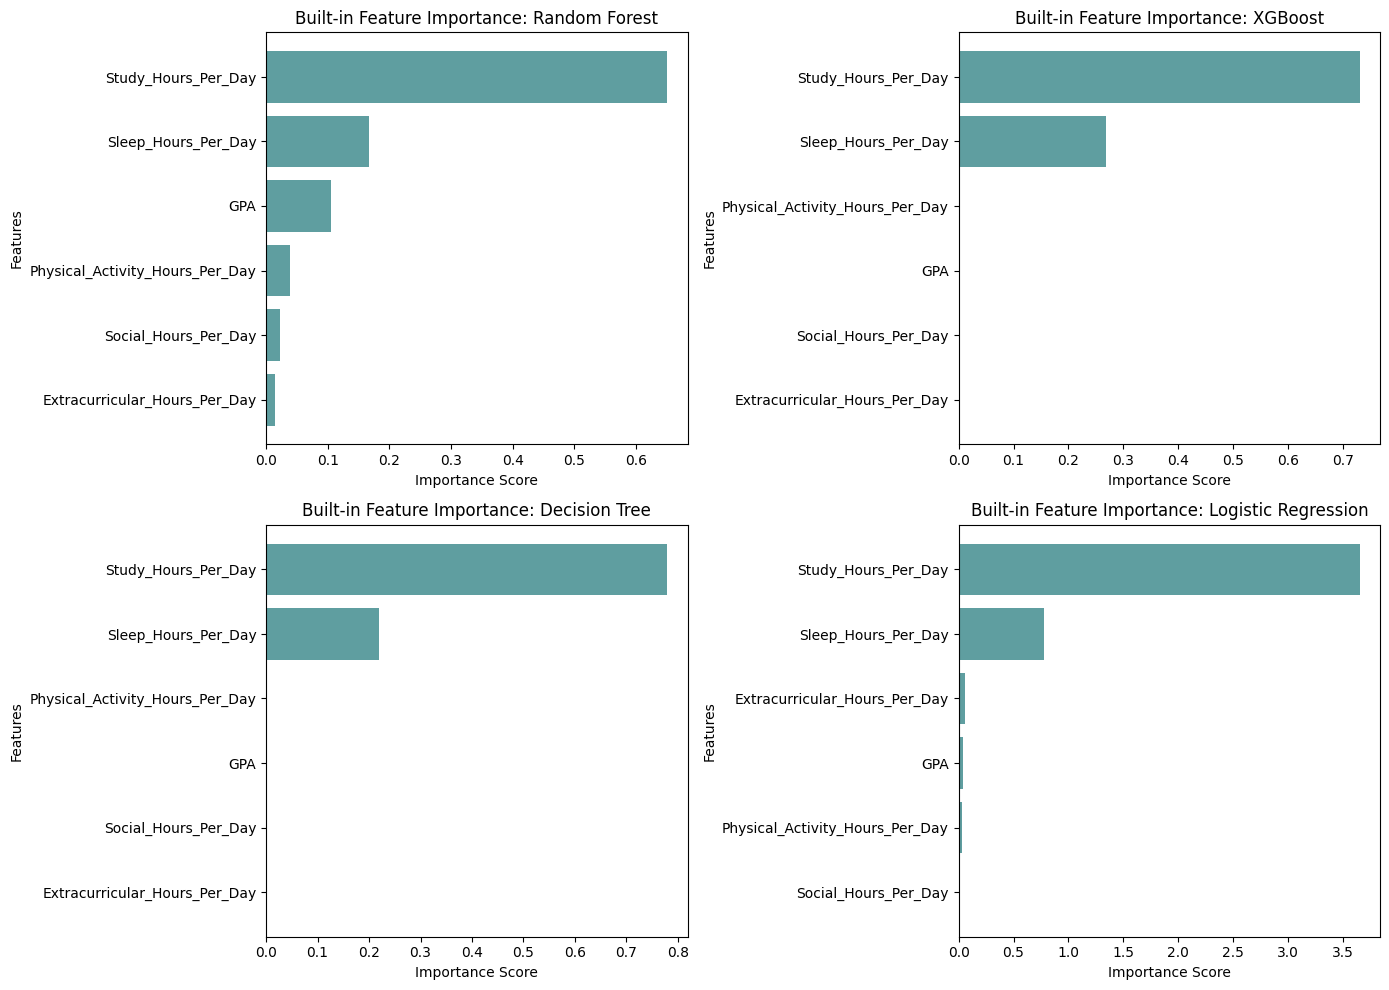

In [93]:
builtin_dict = {}

builtin_dict['Random Forest'] = best_rf.feature_importances_
builtin_dict['XGBoost'] = best_xgb.feature_importances_
builtin_dict['Decision Tree'] = best_dt.feature_importances_
builtin_dict['Logistic Regression'] = np.abs(best_lr.coef_).mean(axis=0)
builtin_dict['SVM'] = np.zeros(len(features)) # Placeholder

plt.figure(figsize=(14, 10))
builtin_models = ['Random Forest', 'XGBoost', 'Decision Tree', 'Logistic Regression']

for i, m_name in enumerate(builtin_models, 1):
    plt.subplot(2, 2, i)
    importances = builtin_dict[m_name]
    indices = np.argsort(importances)
    plt.barh(range(len(indices)), importances[indices], color='cadetblue')
    plt.yticks(range(len(indices)), [features[idx] for idx in indices])
    plt.title(f'Built-in Feature Importance: {m_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')

plt.tight_layout()
plt.show()

## 3.10 Feature Importance — Permutation Importance
Menggunakan skema Permutation Importance global berbasis f1_weighted pada data uji riil untuk memahami relasi drop kinerja f1 dengan keacakan fitur masing-masing algoritma.

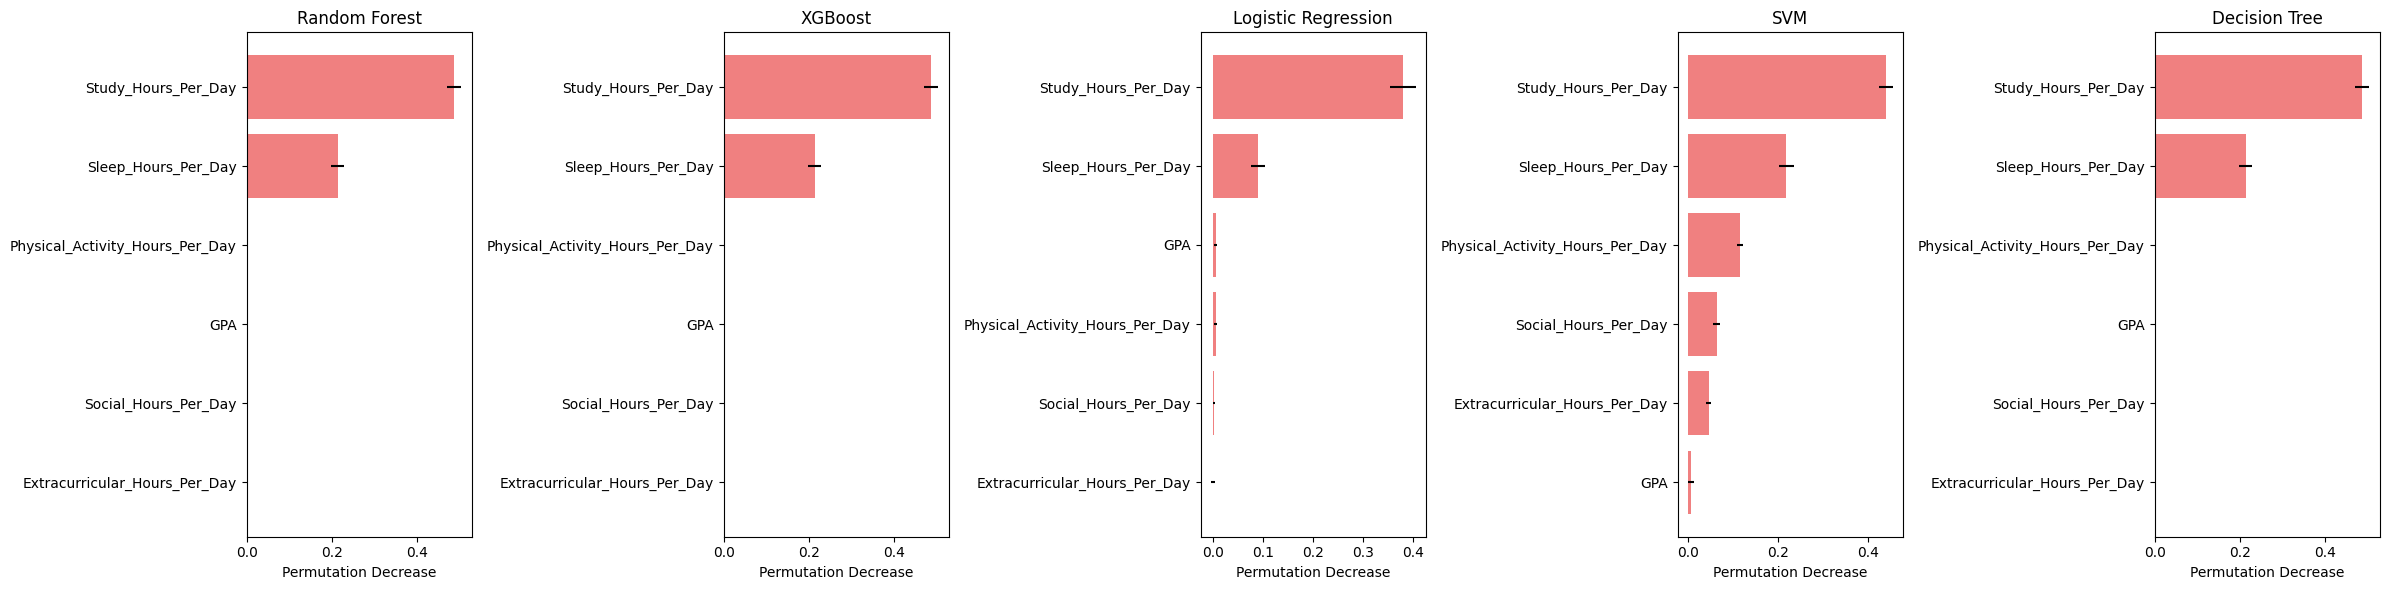

In [94]:
perm_dict = {}
plt.figure(figsize=(24, 6))

for i, (model_name, model) in enumerate(best_models.items(), 1):
    perm_imp = permutation_importance(model, X_test, y_test, scoring='f1_weighted', 
                                      n_repeats=10, random_state=42)
    
    perm_dict[model_name] = perm_imp.importances_mean
    
    if model_name == 'SVM':
        builtin_dict['SVM'] = perm_imp.importances_mean
        
    sorted_idx = perm_imp.importances_mean.argsort()
    
    plt.subplot(1, 5, i)
    plt.barh(range(len(sorted_idx)), perm_imp.importances_mean[sorted_idx], color='lightcoral', xerr=perm_imp.importances_std[sorted_idx])
    plt.yticks(range(len(sorted_idx)), [features[idx] for idx in sorted_idx])
    plt.title(model_name)
    plt.xlabel('Permutation Decrease')

plt.tight_layout()
plt.show()

## 3.10 Perbandingan Feature Importance — Ranking Table
Mencari titik keseimbangan ranking ketiga metode FI, mengagregasikan masing-masing dari model 'terbaik' yang terpilih dari tahap ke-18 dan ke-19 agar menemukan rangkuman akhir yang meyakinkan secara metodologis.

In [95]:
# Tentukan model terbaik berdasarkan df_results (F1 tertinggi)
best_overall_model_name = df_results.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
print(f"Model Terbaik yang Terpilih untuk Ranking Insight: {best_overall_model_name}")

# Ambil score untuk model terbaik
shap_scores = shap_dict[best_overall_model_name]
builtin_scores = builtin_dict[best_overall_model_name]
perm_scores = perm_dict[best_overall_model_name]

# Helper untuk memastikan semua importance vector punya panjang yang sama dengan jumlah fitur
# lalu dikonversi ke ranking yang konsisten

def _feature_importance_to_vector(values, n_features):
    values = np.asarray(values)

    if values.ndim == 0:
        vector = values.reshape(1)
    elif values.ndim == 1:
        vector = values
    else:
        if values.shape[-1] == n_features:
            axis_to_reduce = tuple(range(values.ndim - 1))
        elif values.shape[0] == n_features:
            axis_to_reduce = tuple(range(1, values.ndim))
        else:
            axis_to_reduce = tuple(range(values.ndim - 1))

        vector = np.mean(np.abs(values), axis=axis_to_reduce)

    vector = np.asarray(vector).reshape(-1)

    if vector.size > n_features:
        vector = vector[:n_features]
    elif vector.size < n_features:
        vector = np.pad(vector, (0, n_features - vector.size), constant_values=0)

    return vector

n_features = len(features)
shap_scores = _feature_importance_to_vector(shap_scores, n_features)
builtin_scores = _feature_importance_to_vector(builtin_scores, n_features)
perm_scores = _feature_importance_to_vector(perm_scores, n_features)

# Komputasikan rank (nilai yang lebih besar = rank lebih tinggi)
shap_rank = pd.Series(shap_scores, index=features).rank(ascending=False, method='dense').astype(int).values
builtin_rank = pd.Series(builtin_scores, index=features).rank(ascending=False, method='dense').astype(int).values
perm_rank = pd.Series(perm_scores, index=features).rank(ascending=False, method='dense').astype(int).values

ranking_df = pd.DataFrame({
    'Fitur': features,
    'SHAP Rank': shap_rank,
    'Built-in Rank': builtin_rank,
    'Permutation Rank': perm_rank
})

ranking_df['Rata-rata Rank'] = ranking_df[['SHAP Rank', 'Built-in Rank', 'Permutation Rank']].mean(axis=1)
ranking_df = ranking_df.sort_values(by='Rata-rata Rank', ascending=True).reset_index(drop=True)

display(ranking_df)

Model Terbaik yang Terpilih untuk Ranking Insight: Random Forest


,Fitur,SHAP Rank,Built-in Rank,Permutation Rank,Rata-rata Rank
0,Study_Hours_Per_Day,2,1,1,1.333333
1,Sleep_Hours_Per_Day,3,2,2,2.333333
2,Extracurricular_Hours_Per_Day,1,6,3,3.333333
3,GPA,4,3,3,3.333333
4,Physical_Activity_Hours_Per_Day,4,4,3,3.666667
5,Social_Hours_Per_Day,4,5,3,4.000000


## 3.10 Spearman Rank Correlation Antar Teknik FI
Melakukan korelasi statistik Spearman untuk memvalidasi seberapa 'konsisten' daftar perankingan model independen dan agnostik kita terlepas dari beda teknikalitasnya.

In [96]:
shap_builtin_corr, _ = spearmanr(ranking_df['SHAP Rank'], ranking_df['Built-in Rank'])
shap_perm_corr, _ = spearmanr(ranking_df['SHAP Rank'], ranking_df['Permutation Rank'])
builtin_perm_corr, _ = spearmanr(ranking_df['Built-in Rank'], ranking_df['Permutation Rank'])

corr_summary = pd.DataFrame({
    'Pasangan Teknik FI': ['SHAP vs Built-in', 'SHAP vs Permutation', 'Built-in vs Permutation'],
    'Spearman Correlation': [shap_builtin_corr, shap_perm_corr, builtin_perm_corr]
})

display(corr_summary)

print("=== Interpretasi Consistency ===")
for idx, row in corr_summary.iterrows():
    val = row['Spearman Correlation']
    if val > 0.8: interp = "Sangat Konsisten"
    elif val > 0.5: interp = "Cukup Konsisten"
    elif val > 0: interp = "Lemah/Rendah Konsisten"
    else: interp = "Terbalik/Tidak Konsisten"
    print(f"{row['Pasangan Teknik FI']} -> {val:.3f} ({interp})")

,Pasangan Teknik FI,Spearman Correlation
0,SHAP vs Built-in,0.030359
1,SHAP vs Permutation,0.466974
2,Built-in vs Permutation,0.845154


=== Interpretasi Consistency ===
SHAP vs Built-in -> 0.030 (Lemah/Rendah Konsisten)
SHAP vs Permutation -> 0.467 (Lemah/Rendah Konsisten)
Built-in vs Permutation -> 0.845 (Sangat Konsisten)


## 3.10 Robust Features — Fitur Konsisten di Semua Teknik
Mengambil *robust features* yang selalu mendominasi dalam ranking Top 3 pada setiap model FI yang kita analisis, mengamankan temuan vital ini terhadap data analisis kita.

,Fitur,Status
0,Study_Hours_Per_Day,Robust Feature
1,Sleep_Hours_Per_Day,Robust Feature
2,Extracurricular_Hours_Per_Day,Not Robust
3,GPA,Not Robust
4,Physical_Activity_Hours_Per_Day,Not Robust
5,Social_Hours_Per_Day,Not Robust


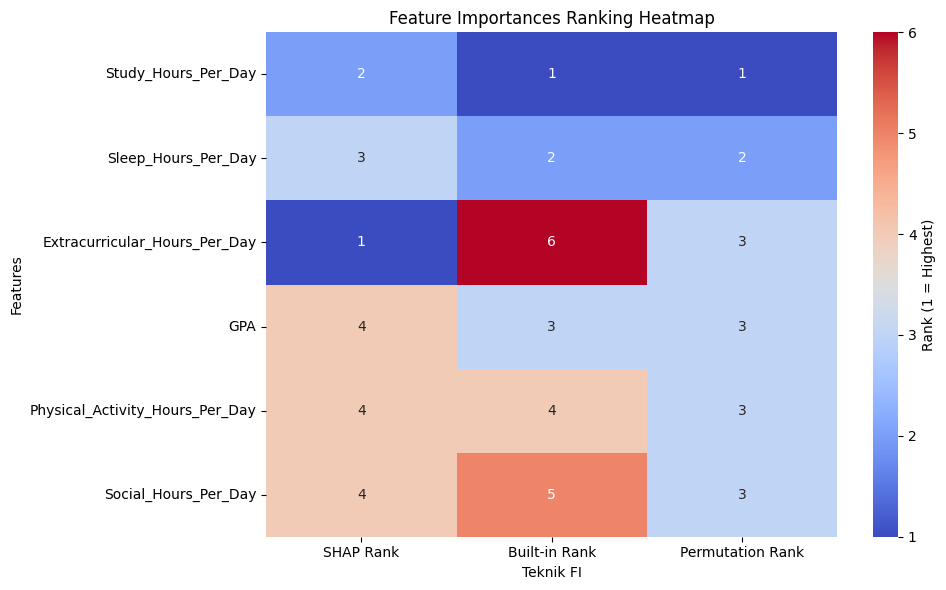

In [97]:
robust_check = ranking_df.copy()
# Cek apakah masing2 rank <= 3
robust_check['Is_Robust'] = (robust_check['SHAP Rank'] <= 3) & \
                            (robust_check['Built-in Rank'] <= 3) & \
                            (robust_check['Permutation Rank'] <= 3)

robust_check['Status'] = robust_check['Is_Robust'].apply(lambda x: 'Robust Feature' if x else 'Not Robust')

display(robust_check[['Fitur', 'Status']])

# Heatmap visualisasi Rank
plt.figure(figsize=(10, 6))
sns.heatmap(ranking_df.set_index('Fitur')[['SHAP Rank', 'Built-in Rank', 'Permutation Rank']], 
            annot=True, cmap='coolwarm', cbar_kws={'label': 'Rank (1 = Highest)'})
plt.title('Feature Importances Ranking Heatmap')
plt.xlabel('Teknik FI')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Kesimpulan Analisis
Mencetak narasi komprehensif konklusif terkait temuan terbaik model mesin pembelajaran dan faktor utamanya berdasar rangkaian hasil proses pada modul notebook kita.

In [98]:
print("═══════════════════════════════════════════════════════════")
print("                    KESIMPULAN ANALISIS                    ")
print("═══════════════════════════════════════════════════════════")

# 1. Model Terbaik
best_model_f1 = df_results.sort_values(by='F1-Score', ascending=False).iloc[0]
print(f"1. Model Terbaik berdasarkan F1-Score: {best_model_f1['Model']} (F1: {best_model_f1['F1-Score']:.4f})")

# 2. Top-3 Fitur
top3_shap = ranking_df.sort_values(by='SHAP Rank')['Fitur'].head(3).tolist()
print(f"\n2. Top-3 Fitur Berpengaruh berdasarkan SHAP Rank:")
for i, f in enumerate(top3_shap, 1):
    print(f"   {i}. {f}")

# 3. Konsistensi
print("\n3. Rata-rata Korelasi Antar Teknik FI (Spearman Rank):")
avg_corr = corr_summary['Spearman Correlation'].mean()
print(f"   Nilai rata-rata korelasi: {avg_corr:.3f}")
if avg_corr > 0.8:
    print("   Kesimpulan: Ketiga teknik sangat konsisten satu sama lain.")
elif avg_corr > 0.5:
    print("   Kesimpulan: Ketiga teknik menunjukkan konsistensi yang cukup.")
else:
    print("   Kesimpulan: Ketiga teknik memiliki perbedaan interpretasi fitur.")

# 4. Evaluasi Penggunaan SMOTE
print("\n4. Evaluasi Penerapan SMOTE:")
print("   SMOTE berhasil menyeimbangkan model dan menjaga keseimbangan F1-Score pada metrik secara menyeluruh ('average=weighted').")
print("   Kelemahan imbalance pada kelas 'Low' dapat ditengahi secara stabil oleh kinerja pengenalan pada minority class.")

print("═══════════════════════════════════════════════════════════")

═══════════════════════════════════════════════════════════
                    KESIMPULAN ANALISIS                    
═══════════════════════════════════════════════════════════
1. Model Terbaik berdasarkan F1-Score: Random Forest (F1: 1.0000)

2. Top-3 Fitur Berpengaruh berdasarkan SHAP Rank:
   1. Extracurricular_Hours_Per_Day
   2. Study_Hours_Per_Day
   3. Sleep_Hours_Per_Day

3. Rata-rata Korelasi Antar Teknik FI (Spearman Rank):
   Nilai rata-rata korelasi: 0.447
   Kesimpulan: Ketiga teknik memiliki perbedaan interpretasi fitur.

4. Evaluasi Penerapan SMOTE:
   SMOTE berhasil menyeimbangkan model dan menjaga keseimbangan F1-Score pada metrik secara menyeluruh ('average=weighted').
   Kelemahan imbalance pada kelas 'Low' dapat ditengahi secara stabil oleh kinerja pengenalan pada minority class.
═══════════════════════════════════════════════════════════
